# Bank Data Analysis Using Python
# Final Project
Developed By: Mohamad


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
              

In [2]:
df = pd.read_csv('BC project.csv')
df.head()

,Date,Transaction_ID,Account_Type,Description,Category,Type,Amount,Balance
0,01-Apr-26,TXN-9001,Checking,Salary Credit - TechCorp,Income,Credit,4500.00,8500.00
1,02-Apr-26,TXN-9002,Checking,City Power & Light,Utilities,Debit,-125.50,8374.50
2,04-Apr-26,TXN-9003,Credit Card,Whole Foods Market,Groceries,Debit,-210.25,8164.25
3,05-Apr-26,TXN-9004,Savings,Auto-Transfer to Savings,Transfer,Debit,-500.00,7664.25
4,06-Apr-26,TXN-9005,Checking,Shell Gas Station,Transport,Debit,-45.00,7619.25


# Data Exploration

In [3]:
print(df.shape)
print(df.info())
df.describe()

(14, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            14 non-null     object 
 1   Transaction_ID  14 non-null     object 
 2   Account_Type    14 non-null     object 
 3   Description     14 non-null     object 
 4   Category        14 non-null     object 
 5   Type            14 non-null     object 
 6   Amount          14 non-null     float64
 7   Balance         14 non-null     float64
dtypes: float64(2), object(6)
memory usage: 1.0+ KB
None


,Amount,Balance
count,14.000000,14.000000
mean,46.055000,6577.767143
std,1412.968369,1377.419141
min,-1500.000000,4626.320000
25%,-427.562500,5829.432500
50%,-67.495000,6204.260000
75%,-13.335000,7653.000000
max,4500.000000,8500.000000


# Data Cleaning

In [5]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
df['Date']=pd.to_datetime(df['Date'])

Date              0
Transaction_ID    0
Account_Type      0
Description       0
Category          0
Type              0
Amount            0
Balance           0
dtype: int64
0


# Feature Engineering

In [6]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)
df.head()

,Date,Transaction_ID,Account_Type,Description,Category,Type,Amount,Balance,Year,Month,Day,Day_of_Week,Is_Weekend
0,2026-04-01,TXN-9001,Checking,Salary Credit - TechCorp,Income,Credit,4500.00,8500.00,2026,4,1,Wednesday,0
1,2026-04-02,TXN-9002,Checking,City Power & Light,Utilities,Debit,-125.50,8374.50,2026,4,2,Thursday,0
2,2026-04-04,TXN-9003,Credit Card,Whole Foods Market,Groceries,Debit,-210.25,8164.25,2026,4,4,Saturday,1
3,2026-04-05,TXN-9004,Savings,Auto-Transfer to Savings,Transfer,Debit,-500.00,7664.25,2026,4,5,Sunday,1
4,2026-04-06,TXN-9005,Checking,Shell Gas Station,Transport,Debit,-45.00,7619.25,2026,4,6,Monday,0


## Business  Questions
Total Account Holders

In [7]:
len(df)

14

# Total Amount

In [8]:
df['Amount'].sum()

644.7700000000002

# Average Amount

In [9]:
df['Amount'].mean()

46.055000000000014

# Account Holders by Type

In [10]:
df['Type'].value_counts()

Type
Debit     11
Credit     3
Name: count, dtype: int64

# Visualization
## Account Type-Wise Customers

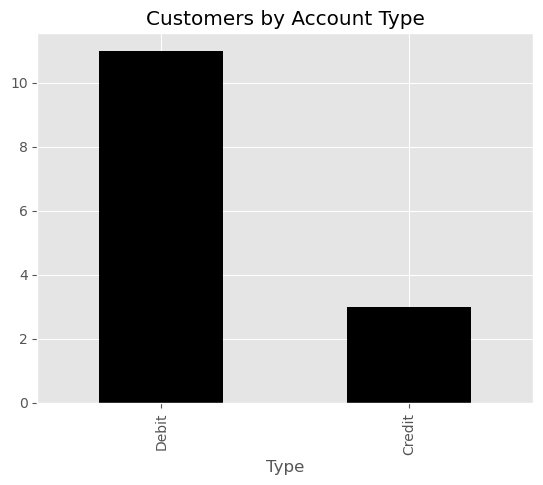

In [11]:
df['Type'].value_counts().plot(kind='bar',color = 'k')
plt.title('Customers by Account Type')
plt.show()

# Category Distrinution

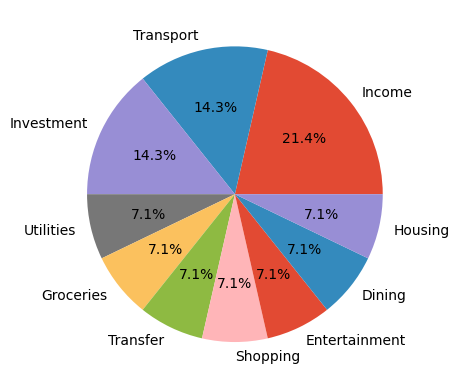

In [12]:
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

# Weekly Customers

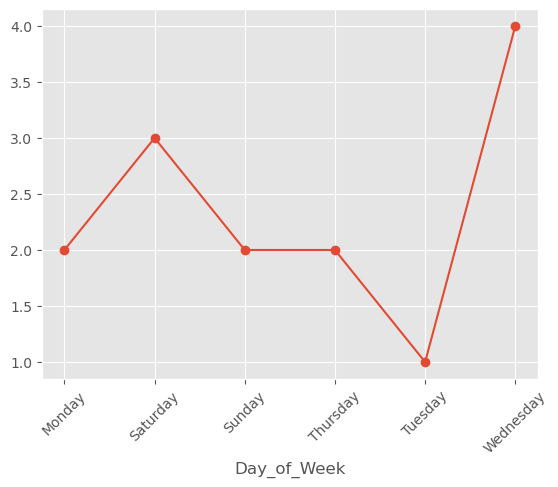

In [20]:
df.groupby('Day_of_Week').size().plot(kind='line',marker='o')
plt.xticks(rotation=45)
plt.show()

# Balance Distribution

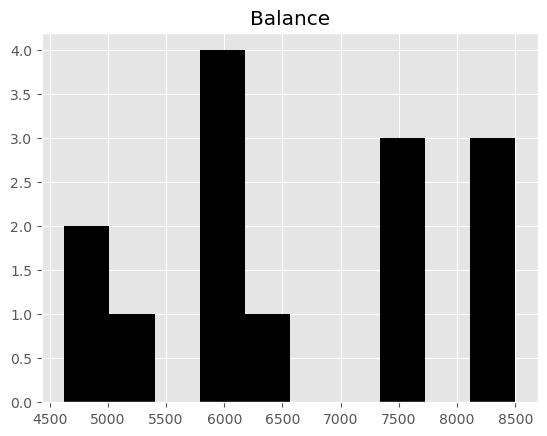

In [23]:
plt.hist(df['Balance'],bins=10,color='k')
plt.title('Balance')
plt.show()

# Day of Week vs Balance

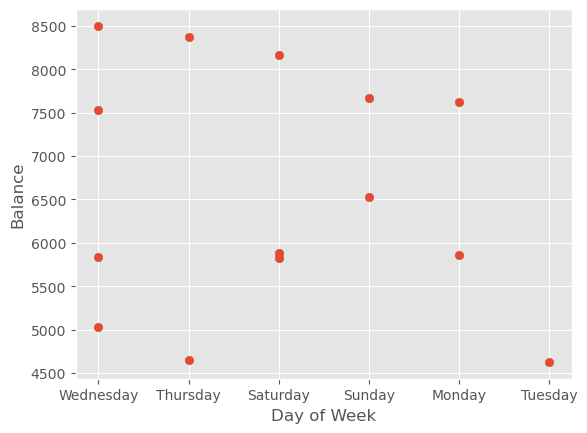

In [27]:
plt.scatter(df['Day_of_Week'], df['Balance'])
plt.xlabel('Day of Week')
plt.ylabel('Balance')
plt.show()

# Bank Insights
- Identify the top Account Holders
- Identify Weekly Customers
- Compare Day of  Week vs Balance
- Recommend marketing strategies